In [1]:
# ============================
# FIRST CODE (valuation + optimal path plot)
# ============================
import numpy as np
import pandas as pd
import numba as nb
from tqdm.auto import tqdm

# ----------------------------
# Load forward prices (deterministic)
# ----------------------------
S = pd.read_csv("../data/forward_prices.csv").iloc[:, 1].to_numpy(dtype=np.float64)
T = S.shape[0]

# ----------------------------
# Model parameters
# ----------------------------
vmin, vmax = 0.0, 250000.0
v0, vT_target = 100000.0, 100000.0
inj_max, wdr_max = 2500.0, 7500.0

alpha = 2500
r_annual = 0.1
terminal_penalty = 1e12

dt = 1.0 / 365.0
disc = np.exp(-r_annual * dt)

# ----------------------------
# Grid
# ----------------------------
v_grid = np.arange(vmin, vmax + alpha, alpha, dtype=np.float64)
N = v_grid.size

def index_of(v: float) -> int:
    return int(round((v - vmin) / alpha))

n0 = index_of(v0)
nT = index_of(vT_target)

def feasible_next_indices(v: float) -> np.ndarray:
    dv_min = max(vmin - v, -wdr_max)
    dv_max = min(vmax - v,  inj_max)

    k_min = int(np.ceil(dv_min / alpha))
    k_max = int(np.floor(dv_max / alpha))

    n = int(round((v - vmin) / alpha))
    idx = n + np.arange(k_min, k_max + 1, dtype=np.int32)

    if idx.size:
        idx = idx[(idx >= 0) & (idx < N)]
    return idx

# ----------------------------
# Precompute feasible moves
# ----------------------------
K_max = 0
for n in range(N):
    K_max = max(K_max, feasible_next_indices(v_grid[n]).size)

next_idx_mat = np.full((N, K_max), -1, dtype=np.int32)
dv_mat       = np.zeros((N, K_max), dtype=np.float64)
K_len        = np.zeros(N, dtype=np.int32)

for n in range(N):
    idxs = feasible_next_indices(v_grid[n])
    k = idxs.size
    K_len[n] = k
    if k:
        next_idx_mat[n, :k] = idxs
        dv_mat[n, :k] = v_grid[idxs] - v_grid[n]

# ----------------------------
# Terminal condition
# ----------------------------
Y_next = np.full(N, -terminal_penalty, dtype=np.float64)
Y_next[nT] = 0.0
Y_current = np.empty(N, dtype=np.float64)

# Policy: store optimal next state for EVERY state at EVERY time
pi = np.full((T, N), -1, dtype=np.int32)

# ----------------------------
# Bellman step (with full policy storage)
# ----------------------------
@nb.njit(fastmath=True)
def bellman_step_with_policy(Y_current, pi_row, S_t, Y_next, disc,
                             next_idx_mat, dv_mat, K_len):
    Nloc = next_idx_mat.shape[0]
    for n in range(Nloc):
        klen = K_len[n]
        if klen == 0:
            Y_current[n] = -np.inf
            pi_row[n] = -1
            continue

        best_val = -np.inf
        best_next = -1
        for k in range(klen):
            nxt = next_idx_mat[n, k]
            cand = (-S_t * dv_mat[n, k]) + disc * Y_next[nxt]
            if cand > best_val:
                best_val = cand
                best_next = nxt

        Y_current[n] = best_val
        pi_row[n] = best_next

# ----------------------------
# Backward induction
# ----------------------------
for t in tqdm(range(T - 1, -1, -1), total=T, desc="Backward induction (intrinsic, deterministic)"):
    bellman_step_with_policy(
        Y_current, pi[t], float(S[t]), Y_next, disc,
        next_idx_mat, dv_mat, K_len
    )
    Y_next, Y_current = Y_current, Y_next

V0 = float(Y_next[n0])
print("V0 =", V0)

# ----------------------------
# Reconstruct optimal volume path forward for plotting
# ----------------------------
n = n0
q_path = np.empty(T + 1, dtype=np.float64)
q_path[0] = v_grid[n0]

for t in range(T):
    n = int(pi[t, n])
    if n < 0:
        raise RuntimeError(f"No feasible policy at t={t}.")
    q_path[t + 1] = v_grid[n]

/Users/rasmus/Library/CloudStorage/OneDrive-AalborgUniversitet/Thesis/P10/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Backward induction (intrinsic, deterministic): 100%|██████████| 731/731 [00:00<00:00, 2010.04it/s]

V0 = 2179050.147967273


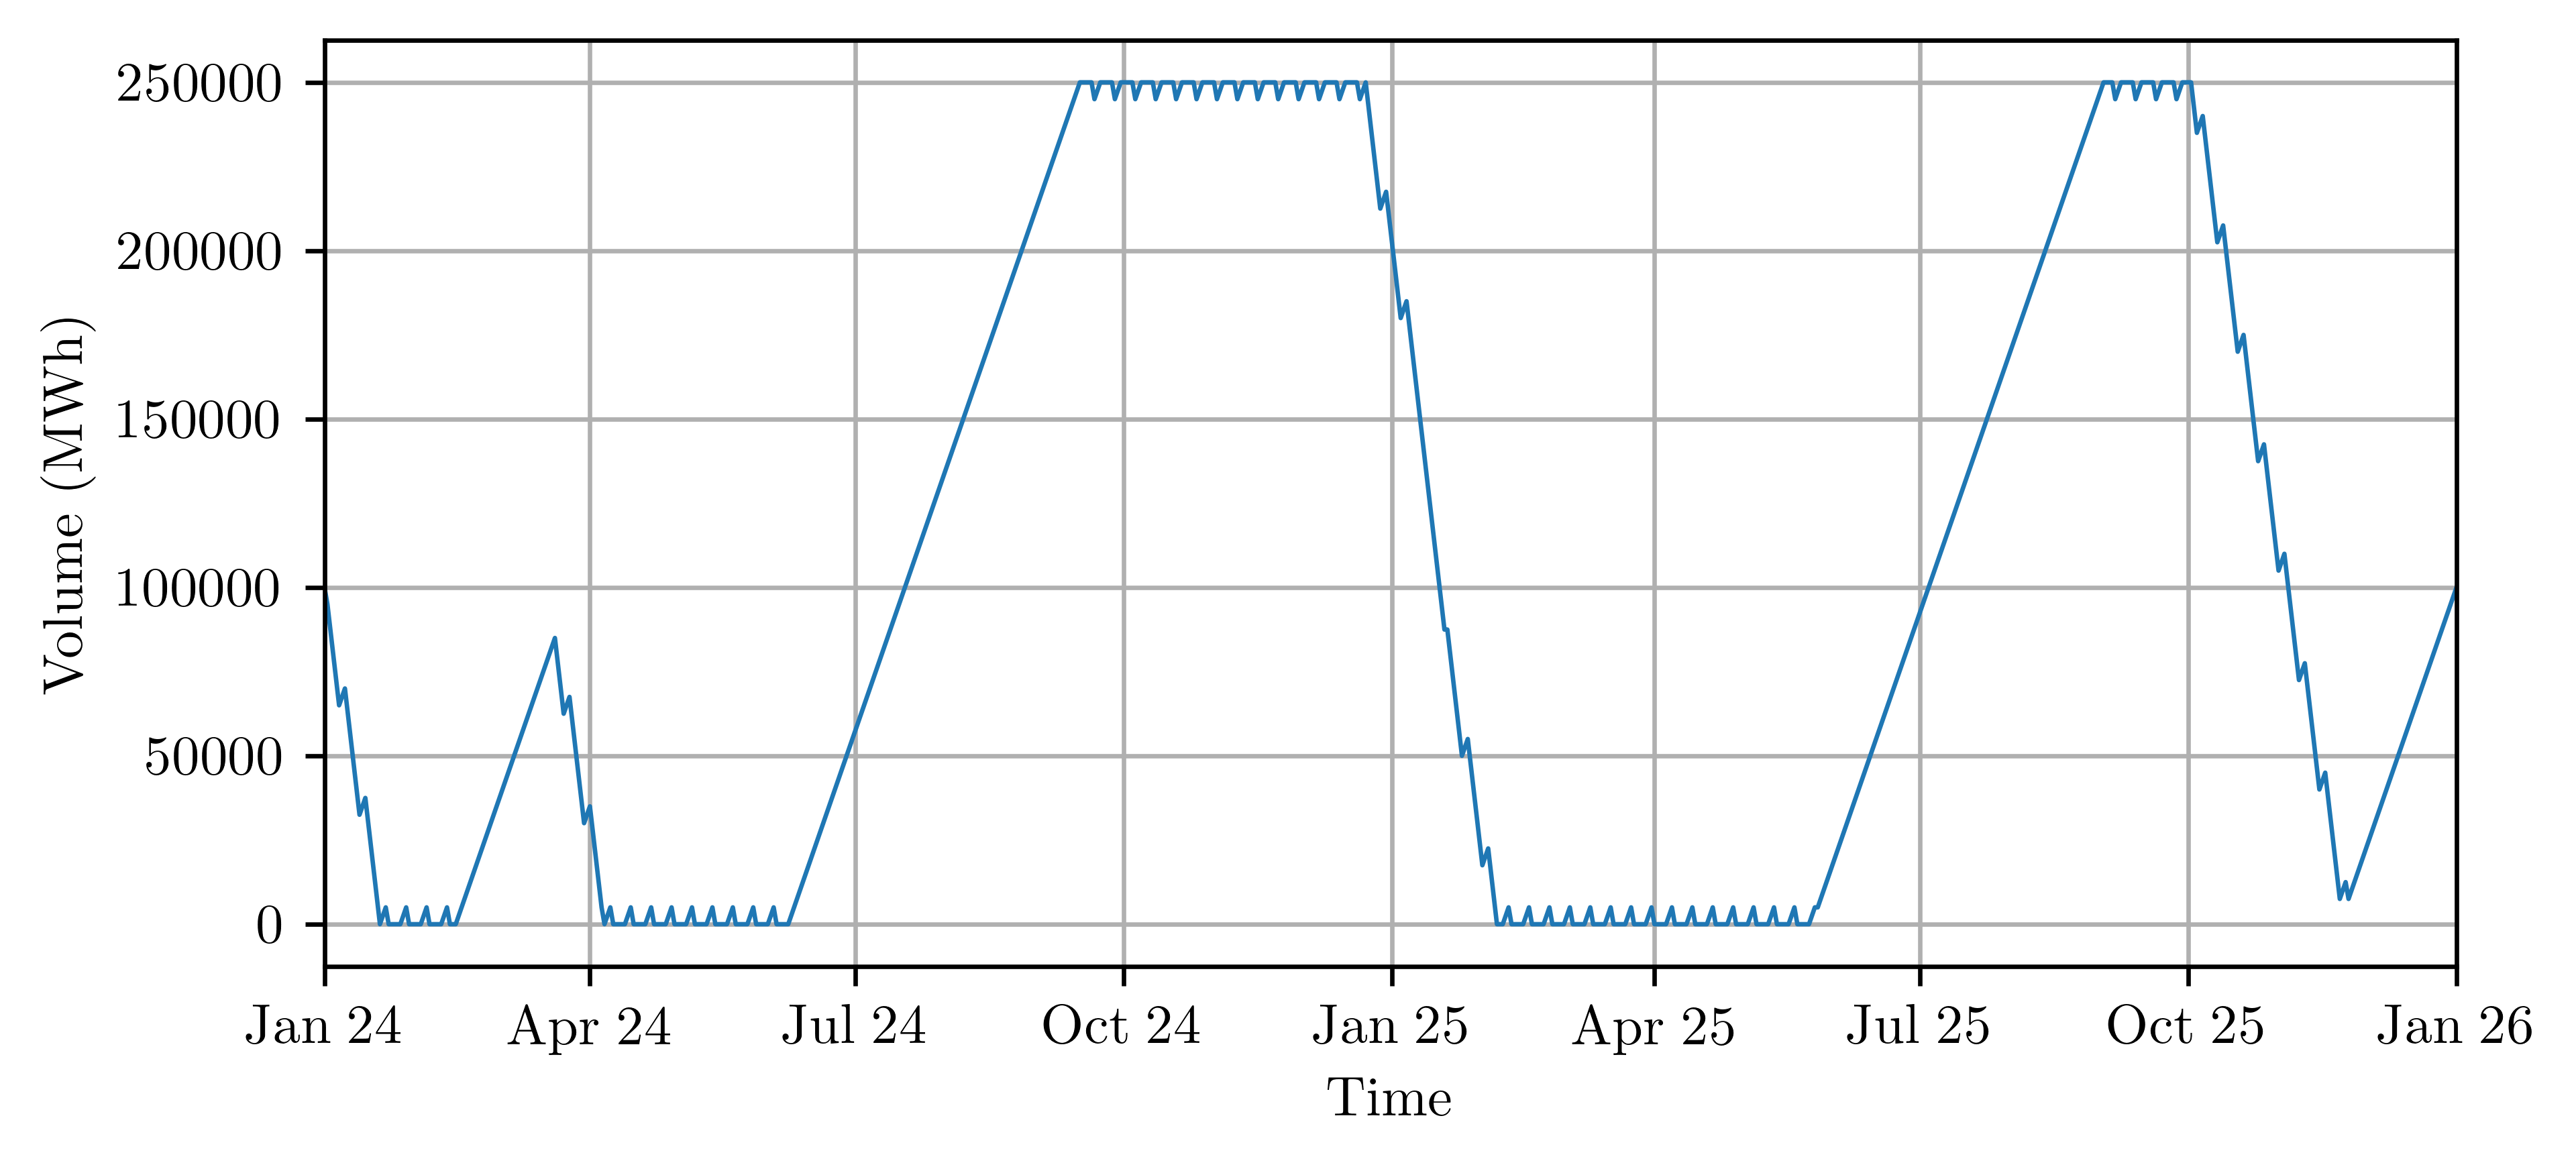

In [3]:
# ----------------------------
# Plot
# ----------------------------
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

start_date = pd.Timestamp("2024-01-01")
dates = pd.date_range(start=start_date, periods=T + 1, freq="D")  # daily grid

fig, ax = plt.subplots(figsize=(6.5, 3), dpi=600)

ax.plot(dates, q_path, linewidth=0.8)

# X ticks every 3 months, starting at Jan 2024
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))

# Y ticks
ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(50000))

ax.set_xlabel("Time")
ax.set_ylabel("Volume (MWh)")
ax.set_xlim(dates[0], dates[-1])
ax.grid(True)

fig.tight_layout()
plt.savefig("../../fig/Plots/intrinsic_valuation_optimal_path.png")
plt.show()


In [6]:
# ============================
# SECOND CODE (table construction consistent with V0)
# ============================
import numpy as np
import pandas as pd

# ----------------------------
# Build cashflows along the realized optimal path (forward simulation)
# This MUST use the full policy matrix pi[t, n] (not pi_next_idx[t]).
# ----------------------------
v_path = np.empty(T + 1, dtype=np.float64)
dv_opt = np.empty(T,     dtype=np.float64)
v_opt  = np.empty(T,     dtype=np.float64)
cf     = np.empty(T,     dtype=np.float64)
cf_acc = np.empty(T,     dtype=np.float64)

v_path[0] = v0
n = n0

# Timing consistent with your Bellman equation:
# Y_t = cashflow_t + disc * Y_{t+1}
# => V0 = sum_{t=0}^{T-1} disc^t * cashflow_t
acc = 0.0
dfactor = 1.0  # disc^t

for t in range(T):
    n_next = int(pi[t, n])
    if n_next < 0:
        raise RuntimeError(f"No feasible policy at t={t}, state index n={n}.")

    v_next = float(v_grid[n_next])
    dv = v_next - v_path[t]
    cashflow = -float(S[t]) * dv

    dv_opt[t] = dv
    v_opt[t]  = v_next
    cf[t]     = cashflow

    acc += dfactor * cashflow
    cf_acc[t] = acc
    dfactor *= disc

    v_path[t + 1] = v_next
    n = n_next

# Sanity check (before rounding):
print("V0 =", V0)
print("Accumulated PV (last row) =", cf_acc[-1])
print("Absolute error =", abs(cf_acc[-1] - V0))

# ----------------------------
# Month labels
# ----------------------------
dates = pd.date_range(start="2025-01-01", periods=T, freq="D") 

# ----------------------------
# Build results table
# ----------------------------
results = pd.DataFrame({
    "day": dates.strftime("%d-%b-%Y"),
    "price": S[:T],   # do NOT round here
    "optimal_volume_change": dv_opt,
    "optimal_volume": v_opt,
    "cashflow": cf,
    "accumulated_cashflow": cf_acc,
})

# Integers for everything except price
int_cols = ["optimal_volume_change", "optimal_volume", "cashflow", "accumulated_cashflow"]
results[int_cols] = np.rint(results[int_cols]).astype("int64")

# Export with fixed 2-decimal formatting for floats
results.to_csv(
    "../../fig/Tables/intrinsic_optimal_path.csv",
    index=False,
    float_format="%.2f"
)

V0 = 2179050.147967273
Accumulated PV (last row) = 2179050.1479672734
Absolute error = 4.656612873077393e-10
